## Visualizing Previously Saved Data

This notebook allows you to load and visualize results that were generated in an earlier run.  
Before doing so, we need to define several general parameters that specify where the data is located and how it should be processed.

### Parameter Overview

- **`YOUR_DATA_PATH`**  
  Specifies the directory containing the image data you want to visualize.  
  This can be raw images or preprocessed images—your choice.

- **`GRAPH_OUTPUT_PATH`**  
  Defines the folder where newly generated outputs (such as plots or derived tracks) will be saved.

- **`IMAGE_CHANNEL`**  
  Determines which color channel of the input images should be used for analysis. If the images are grayscale use any:  
  `0 = red`, `1 = green`, `2 = blue`.

- **`SAVED_PATHS`**  
  Points to the file or directory containing previously computed cell tracks that you want to load and explore.

In [130]:
import os
WORK_DIR = os.getcwd()
PATH_OF_SRC_MODUL = WORK_DIR.replace("notebooks", "src")
YOUR_DATA_PATH = r"\\sc-data.sc-store.charite.de\sc-project-cc06-agsack\noja11\CellTrack\unregistered\lck-lyve_caudal-fin_lower-side"
GRAPH_OUTPUT_PATH = r"\\sc-data.sc-store.charite.de\sc-project-cc06-agsack\noja11\CellTrack\unregistered\output"
SAVED_PATHS = r"\\sc-data.sc-store.charite.de\sc-project-cc06-agsack\noja11\CellTrack\unregistered\output\calc_paths.npy"
IMAGE_CHANNEL = 1

os.makedirs(GRAPH_OUTPUT_PATH, exist_ok=True)

Before loading the data or running any analysis, we first need to import all necessary Python packages and modules that the notebook depends on.

In [131]:
import sys
sys.path.append(PATH_OF_SRC_MODUL)
import algo_funcs as algo
import display_funcs as disp
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random

### Reading the Images

Just as in the testing and processing workflow, we need to specify how the cell-tracking algorithm should find and read the image files.  
We assume that your raw image sequence is located in the directory defined by `YOUR_DATA_PATH`.

Most time-series datasets follow a consistent naming scheme.  
For example, if your images are named:

`XXXX_01.tif`, `XXXX_02.tif`, …, `XXXX_NN.tif`

where `XXXX` is a fixed prefix and the numbers indicate the timepoints, then the variable `IMAGE_PATHS_PATTERN` should be defined as:

IMAGE_PATHS_PATTERN = rf'{YOUR_DATA_PATH}/XXXX_*.tif'

This pattern instructs to load all files that follow the specified naming structure.

In [ ]:
IMAGE_PATHS_PATTERN = rf'{YOUR_DATA_PATH}/lyve-dsRed_lck-GFP_DOB-12-8-2024_Fish-8_2mpf_Tail-fin_lower-side_t*.tif'
algo.IMAGE_CHANNEL = IMAGE_CHANNEL

With the file pattern defined, we can now load the images into memory and rescale them to [0,255].

In [124]:
images = algo.read_images(directory = IMAGE_PATHS_PATTERN, is_gray_scale = False)
images = algo.batch_rescale_rgb_to_255(images)
images_unchanged = images.copy()

Next, we load the previously calculated cell paths so they can be visualized and analyzed alongside the images.

In [125]:
dict_list = np.load(SAVED_PATHS, allow_pickle=True)

### Visualizing the Cell Paths

With the tracks loaded, we can now start exploring the reconstructed trajectories.  
In this step, we calculate the mean square displacement (MSD) for each tracked cell and plot the resulting MSD curves.  
The generated figure is automatically saved to:

`{GRAPH_OUTPUT_PATH}/msd.png`

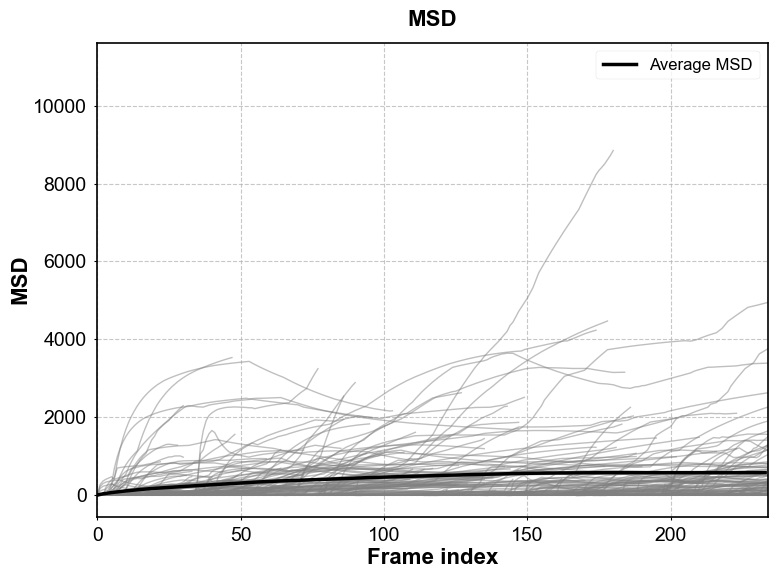

In [126]:
all_paths = [entry["Path"] for entry in dict_list]
all_starting_indices = [entry["StartIndex"] for entry in dict_list]
msd_list = disp.calculate_mean_square_displacement(paths = all_paths)
disp.plot_mean_square_displacement(msd_list = msd_list, starting_indices = all_starting_indices, title = "MSD")
plt.savefig(rf"{GRAPH_OUTPUT_PATH}/msd.png", bbox_inches='tight')

You can also filter and visualize the cell tracks based on their mean square displacement. Below are a few examples demonstrating how different MSD thresholds affect which paths are displayed.

The generated figure is automatically saved to:

`{GRAPH_OUTPUT_PATH}/msd_filtered.png`

714


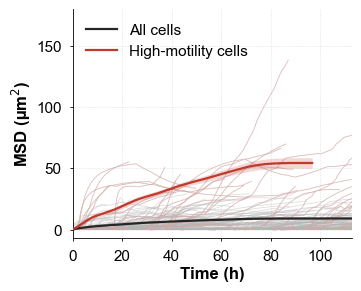

In [127]:
# Plot the MSD of all paths where the absolute of their average direction is at least bigger than 0.05
#all_paths = [entry["Path"] for entry in dict_list if abs(entry["AverageDir"][0]**2+entry["AverageDir"][1]**2)>0.05] 
#all_starting_indices = [entry["StartIndex"] for entry in dict_list if abs(entry["AverageDir"][0]**2+entry["AverageDir"][1]**2)>0.05]

# Plot the MSD of all paths that have a length of at least 150 images
#all_paths = [entry["Path"] for entry in dict_list if (np.array(entry["Path"])[:,1] < 150).all()] 
#all_starting_indices = [entry["StartIndex"] for entry in dict_list if (np.array(entry["Path"])[:,1] < 150).all()]

# Plot the MSD of all paths that have a length between 50 and 100 images
#all_paths = [entry["Path"] for entry in dict_list if len(entry["Path"]) < 100 and len(entry["Path"]) > 50] 
#all_starting_indices = [entry["StartIndex"] for entry in dict_list if len(entry["Path"]) < 100 and len(entry["Path"]) > 50]

# Plot the MSD of all paths that have a MSD higher than 50
all_paths_filtered = [entry["Path"] for entry in dict_list if np.max(disp.calculate_mean_square_displacement([entry["Path"]]))>2000] 
all_starting_indices_filtered = [entry["StartIndex"] for entry in dict_list if np.max(disp.calculate_mean_square_displacement([entry["Path"]]))>2000]

print(len(all_paths))
msd_list_filtered = disp.calculate_mean_square_displacement(paths = all_paths_filtered)
disp.plot_mean_square_displacement_filtered(msd_list_filtered = msd_list_filtered, msd_list = msd_list,starting_indices_filtered = all_starting_indices_filtered, starting_indices = all_starting_indices, title = "Filtered MSD", base_fontsize = 12)
plt.savefig(rf"{GRAPH_OUTPUT_PATH}/msd_filtered.svg", bbox_inches='tight')

Another useful visualization is to normalize all trajectories so that they start at the coordinate (0, 0). This makes it easy to compare the overall movement patterns and observe how the cells diverge over time. Just like with the MSD-based plots, you can also apply filters to display only specific subsets of these normalized paths.

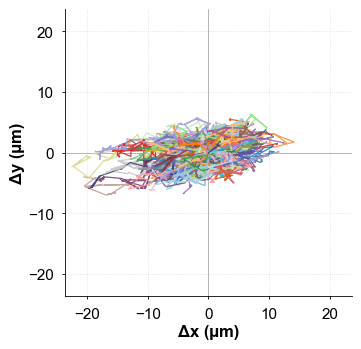

In [128]:
#all_paths_long = [path for path in all_paths if len(path)>20]

disp.plot_normalized_paths(paths = all_paths, base_fontsize=12,pixel_size=0.125)
plt.savefig(rf"{GRAPH_OUTPUT_PATH}/normalized_paths.svg", bbox_inches='tight')

Now let's take a look at the actual image and how the reconstructed paths appear on top of it. You can adjust `zoom_x` and `zoom_y` to zoom into different regions of the image for a closer inspection. `frame` specifies which timepoint (image index) should be displayed. This allows you to overlay the paths on any frame of the sequence.

The generated visualization is saved automatically to:

`{GRAPH_OUTPUT_PATH}/paths_on_image.png`

In [129]:
fig, ax = disp.plot_tracks_3d_with_image_planes(
    images=np.array(images_unchanged),
    tracks=dict_list,
    plane_alpha = 0.5
)
fig.savefig(rf"{GRAPH_OUTPUT_PATH}/paths_3D.svg", bbox_inches="tight")

ValueError: images must have shape (T, H, W) or (T, H, W, C).

In [ ]:
dict_list_filtered = [entry for entry in dict_list if np.max(disp.calculate_mean_square_displacement([entry["Path"]]))>1000] 
all_tracks = [
    {
        "StartIndex": entry["StartIndex"],
        "Frames": list(range(entry["StartIndex"], entry["StartIndex"] + len(entry["Path"]))),
        "Path": entry["Path"],
    }
    for i, entry in enumerate(dict_list_filtered)
]

fig, ax = disp.plot_paths_on_image(
    algo.clip_images(images_unchanged,clip_percentile=99), all_tracks,
    frame=63, channel=1, marker_size=8
)
fig.savefig(rf"{GRAPH_OUTPUT_PATH}/paths_filtered.svg", bbox_inches="tight")

You can also create a video from the reconstructed paths and images.

In [ ]:
frame_width = images_unchanged[0].shape[1]
frame_height = images_unchanged[0].shape[0]
fps = 10 
output_video = cv2.VideoWriter(f"{GRAPH_OUTPUT_PATH}/paths.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

def generate_random_color():
    return (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))

path_colors = [generate_random_color() for _ in all_paths] 

for idx, image in enumerate(images_unchanged):
    img = cv2.cvtColor(images[idx], cv2.COLOR_RGB2RGBA)
    
    for path_idx, path in enumerate(all_paths):
        path_color = path_colors[path_idx]
        alpha = 255

        for i in range(1, len(path)):
            start_point = (int(path[i-1][0]), int(path[i-1][1]))
            end_point = (int(path[i][0]), int(path[i][1]))

            bgr_color = (path_color[0], path_color[1], path_color[2], alpha)
            
            cv2.line(img, start_point, end_point, bgr_color, 1)

    img_bgr = cv2.flip(cv2.cvtColor(img, cv2.COLOR_BGRA2RGB),0)
    output_video.write(img_bgr)

output_video.release()

print("Video created successfully.")